In [23]:
import numpy as np
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import py_vollib_vectorized
import os

from configs.analysis_heston.full_heston_config_1 import FullConfig
from configs.base.env_cfg import device, torch_dtype
from utils.log_print import LogPrint
from utils.pricing import QuantLibHestonModel

from  utils.pricing import bs_delta_from_iv, heston_delta_slice
from utils.analysis import bootstrap_implied_vol, plot_iv_smile
from utils.pricing import bs_delta_from_iv
from src.data_processing import make_state_t
from utils.model_saver import (
    load_market_and_critic0,
    load_actor,
    load_critic_lambda
)
from src.rl_models import q_diff_risk_lambda, q_diff_critic_risk_lambda
# === 核心替换：我们自己的 Heston / FFT / MC ===
from src.heston_model import sim_heston_paths
from utils.pricing import fft_option_prices, fft_bump_delta


In [24]:
LOAD_DIR = (
    "models/"
    "heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5__trans_cost0_005"
)
# LOAD_DIR = (
#     "models/heston_V00_04__kappa4_0__theta0_035__sigma0_3__rho_0_35"
# )

In [25]:
K_GRID = np.linspace(70, 130, 100)
K_GRID = np.linspace(60, 140, 100)
LAMBDA_GRID = [
    0, 0.5, 5, 20, 50,
]
ACTOR_LAMBDA = 100000

In [26]:
# =============================================================================
# Load market, actor, critic0
# =============================================================================
log_print = LogPrint(
    print_debug=True,
    save_dir=os.path.join(LOAD_DIR, "logs"),
    prefix="analysis_section_4_1",
)
with torch.no_grad():

    critic0, market_cfg, critic0_cfg, runtime_cfg = load_market_and_critic0(
        log_print=log_print,
        load_dir=LOAD_DIR,
        device=device,
        torch_dtype=torch_dtype,
    )

    actor, actor_cfg = load_actor(
        log_print=log_print,
        load_dir=LOAD_DIR,
        actor_lambda=ACTOR_LAMBDA,
        device=device,
        torch_dtype=torch_dtype,
    )
    critic, critic_cfg = load_critic_lambda(
            log_print=log_print,
            load_dir=LOAD_DIR,
            actor_lambda=ACTOR_LAMBDA,
            critic_lambda=ACTOR_LAMBDA,
            device=device,
            torch_dtype=torch_dtype,
    )


当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5__trans_cost0_005
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

[ActorLoader] Loaded actor λ=100000
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5__trans_cost0_005/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32
[CriticLoader] Loaded critic λ=100000
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5__trans_cost0_005/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps


In [27]:
S0 = market_cfg.S0
V0 = market_cfg.V0

mu = market_cfg.mu
kappa= market_cfg.kappa
theta = market_cfg.theta
sigma = market_cfg.sigma
rho = market_cfg.rho

r = market_cfg.r
T = market_cfg.T
# T = 0.5
T_steps = market_cfg.T_steps
K = market_cfg.S0             # ATM
option_type = "put"           # 保持不变


In [39]:
T

0.25

In [28]:

@torch.no_grad()
def acc_slice(
        actor, critic0, critic,
        S0,
        K_GRID,
        actor_risk_lambda: float,
        all_critic_risk_lambda: list,
        t,
        device, torch_dtype,
):
    K_GRID = torch.tensor(K_GRID, device=device, dtype=torch_dtype)
    S_over_K = S0 / K_GRID
    state = make_state_t(
        torch.tensor(S_over_K, device=device, dtype=torch_dtype),
        torch.tensor(t, device=device, dtype=torch_dtype),
    )
    actions = actor.mean(state)

    # state.repeat(50, 1, 1)

    QQ = q_diff_critic_risk_lambda(
        critic0=critic0,
        critic=critic,
        actions=actions,
        actor_risk_lambda=actor_risk_lambda,
        all_critic_risk_lambda=all_critic_risk_lambda,
        state=state,
    )

    return - QQ * K_GRID, actions * (K_GRID / S0)

all_q, actions = acc_slice(
    actor, critic0, critic,
    S0,
    K_GRID,
    actor_risk_lambda = ACTOR_LAMBDA,
    all_critic_risk_lambda = LAMBDA_GRID,
    t = T,
    device=device,
    torch_dtype=torch_dtype,
)
all_q = all_q[:,0]


/var/folders/sl/0y225v_53s51ql32byt5jkcm0000gn/T/ipykernel_87129/1602730966.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(S_over_K, device=device, dtype=torch_dtype),


In [29]:
K_tensor = torch.tensor(K_GRID, device=device, dtype=torch_dtype)

S_tensor = torch.full_like(K_tensor, S0, device=device, dtype=torch_dtype)
V_tensor = torch.full_like(K_tensor, V0, device=device, dtype=torch_dtype)
T_tensor = torch.full_like(K_tensor, T, device=device, dtype=torch_dtype)
r_tensor = torch.full_like(K_tensor, r, device=device, dtype=torch_dtype)
kappa = torch.full_like(K_tensor, kappa, device=device, dtype=torch_dtype)
theta = torch.full_like(K_tensor, theta, device=device, dtype=torch_dtype)
sigma = torch.full_like(K_tensor, sigma, device=device, dtype=torch_dtype)
rho = torch.full_like(K_tensor, rho, device=device, dtype=torch_dtype)
option_types = torch.full_like(K_tensor, 0, device=device)
# price_fft = fft_option_prices(
#     S=S_tensor,
#     V=V_tensor,
#     K=K_tensor,
#     T=T_tensor,
#     r=r_tensor,
#     kappa=kappa,
#     theta = theta,
#     sigma=sigma,
#     rho=rho,
#     option_types=option_types,
# ).cpu().numpy()
#
# iv_fft = py_vollib_vectorized.vectorized_implied_volatility(
#     price=price_fft,
#     S=S0,
#     K=K_GRID,
#     t=T,
#     r=r,
#     q=0,
#     flag='p',
#     model="black_scholes_merton",
#     on_error="ignore",
#     return_as="numpy",
# )

In [30]:
ql_heston_model = QuantLibHestonModel(
    market_cfg=market_cfg,
    engine_type="analytic",
)
ql_price = np.array([
    ql_heston_model._analytic_price(
        S_t=S0,
        V_t=V0,
        K=K,
        tau=T,
    )
    for K in K_GRID
])

ql_delta = heston_delta_slice(
    heston_model=ql_heston_model,
    S0=S0,
    v0=V0,
    K_array=K_GRID,
    T=T,
)
ql_iv = py_vollib_vectorized.vectorized_implied_volatility(
    price=ql_price,
    S=S0,
    K=K_GRID,
    t=T,
    r=r,
    q=0,
    flag='p',
    model="black_scholes_merton",
    on_error="ignore",
    return_as="numpy",
)

In [31]:
np.full_like(ql_price,0)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [32]:
diff_price_all = {
}
price_all = {
    # 'heston price': price_fft,
    'ql heston price': ql_price,
}
delta_all = {
    'ql delta': ql_delta,
    'ACC-Actor Actions': actions.cpu().numpy(),
}
iv_all = {
    # 'heston fft': iv_fft,
    'ql heston': ql_iv,
}
for i, L in enumerate(LAMBDA_GRID):
    prices = all_q[i].cpu().numpy()
    diff_price_all[f'Price Diff ACC-Critic L={L}'] = (prices - ql_price)
    price_all[f'Price ACC-Critic L={L}'] = prices
    iv_all[f'IV ACC-Critic L={L}'] = py_vollib_vectorized.vectorized_implied_volatility(
                price=prices,
                S=S0,
                K=K_GRID,
                t=T,
                r=r,
                q=0,
                flag='p',
                model="black_scholes_merton",
                on_error="ignore",
                return_as="numpy",
            )

In [33]:
K_GRID

array([ 60.        ,  60.80808081,  61.61616162,  62.42424242,
        63.23232323,  64.04040404,  64.84848485,  65.65656566,
        66.46464646,  67.27272727,  68.08080808,  68.88888889,
        69.6969697 ,  70.50505051,  71.31313131,  72.12121212,
        72.92929293,  73.73737374,  74.54545455,  75.35353535,
        76.16161616,  76.96969697,  77.77777778,  78.58585859,
        79.39393939,  80.2020202 ,  81.01010101,  81.81818182,
        82.62626263,  83.43434343,  84.24242424,  85.05050505,
        85.85858586,  86.66666667,  87.47474747,  88.28282828,
        89.09090909,  89.8989899 ,  90.70707071,  91.51515152,
        92.32323232,  93.13131313,  93.93939394,  94.74747475,
        95.55555556,  96.36363636,  97.17171717,  97.97979798,
        98.78787879,  99.5959596 , 100.4040404 , 101.21212121,
       102.02020202, 102.82828283, 103.63636364, 104.44444444,
       105.25252525, 106.06060606, 106.86868687, 107.67676768,
       108.48484848, 109.29292929, 110.1010101 , 110.90

In [34]:
def plot_img(x_grid, all_data, title, xlabel='Strike Price', ylabel='BS Implied Volatility'):

    import matplotlib.pyplot as plt
    import numpy as np
    # 画图
    plt.figure(figsize=(10, 5))

    # 遍历字典，每条线画一次
    for name, data in all_data.items():
        plt.plot(x_grid, data, label=name)  # label 就是图例名字

    # 加上图例、标签
    plt.legend()          # 显示每条线名字
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


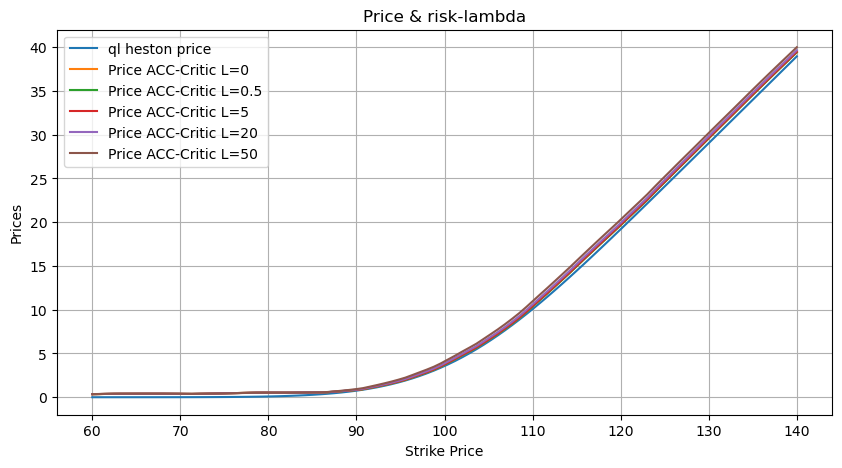

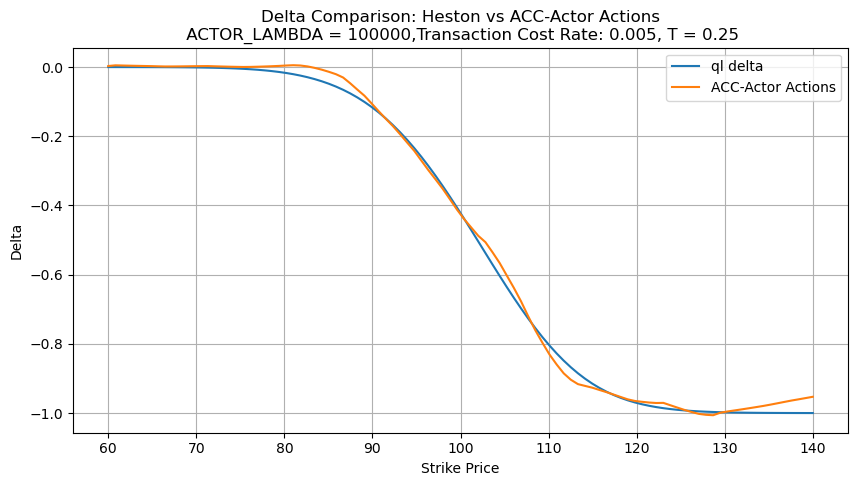

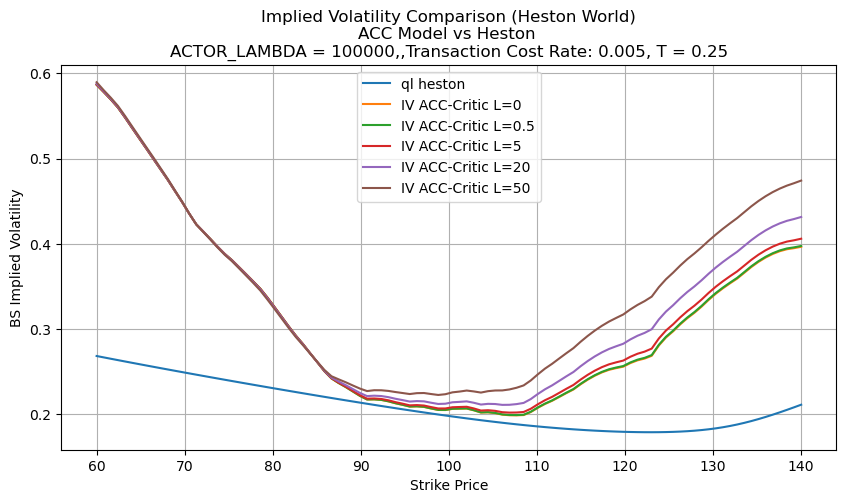

In [35]:
plot_img(K_GRID, price_all, "Price & risk-lambda", xlabel='Strike Price', ylabel='Prices')
plot_img(K_GRID, delta_all,
         f"Delta Comparison: Heston vs ACC-Actor Actions"
         f"\n ACTOR_LAMBDA = {ACTOR_LAMBDA},Transaction Cost Rate: {market_cfg.transaction_cost_rate}, T = {T}",
         xlabel='Strike Price',
         ylabel='Delta',
         )
plot_img(K_GRID, iv_all,
        "Implied Volatility Comparison (Heston World)\n"
        f"ACC Model vs Heston \n"
        f"ACTOR_LAMBDA = {ACTOR_LAMBDA},,Transaction Cost Rate: {market_cfg.transaction_cost_rate}, T = {T}"
         )


In [36]:
import pandas as pd
data = price_all.copy()
data['K_GRID'] = K_GRID
data = pd.DataFrame(data)
data

,ql heston price,Price ACC-Critic L=0,Price ACC-Critic L=0.5,Price ACC-Critic L=5,Price ACC-Critic L=20,Price ACC-Critic L=50,K_GRID
0,0.000133,0.347681,0.347779,0.348664,0.351614,0.357513,60.000000
1,0.000184,0.362859,0.362930,0.363568,0.365696,0.369952,60.808081
2,0.000255,0.377559,0.377630,0.378266,0.380386,0.384625,61.616162
3,0.000349,0.389821,0.389891,0.390525,0.392637,0.396862,62.424242
4,0.000477,0.393997,0.394068,0.394700,0.396807,0.401021,63.232323
...,...,...,...,...,...,...,...
95,35.749245,36.300243,36.306171,36.359558,36.537521,36.893436,136.767677
96,36.551148,37.086758,37.092648,37.145660,37.322376,37.675808,137.575758
97,37.353085,37.867889,37.873741,37.926411,38.101974,38.453098,138.383838
98,38.155050,38.643768,38.649586,38.701962,38.876553,39.225727,139.191919


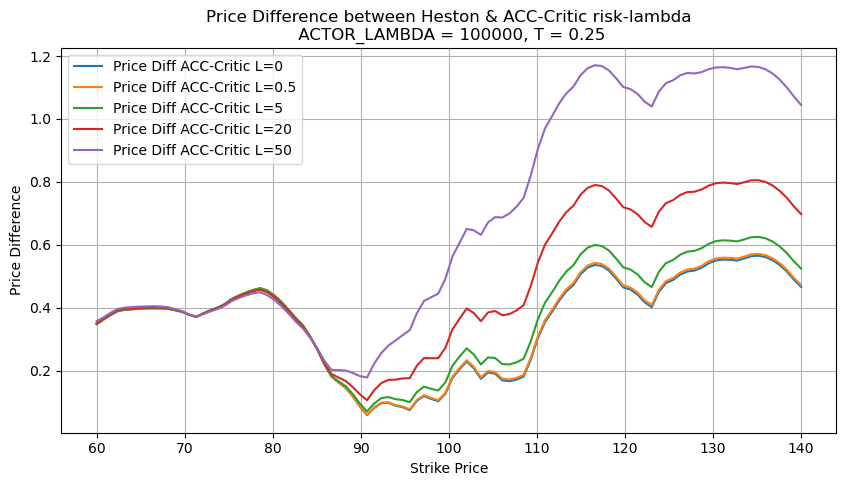

In [37]:
plot_img(K_GRID, diff_price_all, f"Price Difference between Heston & ACC-Critic risk-lambda\n ACTOR_LAMBDA = {ACTOR_LAMBDA}, T = {T}", xlabel='Strike Price', ylabel='Price Difference')


In [38]:
diff_price_all

{'Price Diff ACC-Critic L=0': array([0.34754835, 0.36267433, 0.37730469, 0.38947126, 0.39352091,
        0.39501334, 0.39646906, 0.39793355, 0.39802566, 0.39788736,
        0.39709295, 0.39197536, 0.38702285, 0.37743357, 0.37131936,
        0.3822621 , 0.39210055, 0.40069871, 0.41149635, 0.42818591,
        0.43919283, 0.44877043, 0.45664536, 0.46250272, 0.45464404,
        0.43876477, 0.41803221, 0.39304475, 0.36708986, 0.3436526 ,
        0.30834801, 0.26784725, 0.21992504, 0.18058533, 0.16202902,
        0.14476861, 0.11797855, 0.08541573, 0.05828429, 0.08150528,
        0.09678351, 0.09787142, 0.08854613, 0.08380189, 0.07439318,
        0.10411952, 0.11918495, 0.10992406, 0.10282135, 0.12602862,
        0.17692537, 0.20444333, 0.22900537, 0.20743687, 0.17395379,
        0.19427671, 0.19026522, 0.16921744, 0.16637624, 0.17145962,
        0.18090969, 0.23464236, 0.30305784, 0.35420321, 0.3871532 ,
        0.42268834, 0.45223834, 0.47214438, 0.50665007, 0.52769357,
        0.53607332,